# Question 4: Search Algorithms and Complexity Analysis

## Introduction

Search algorithms locate target values within a dataset. In an e-commerce platform handling thousands to millions of product records, the choice between **Linear Search** and **Binary Search** directly affects response time under heavy traffic. This notebook implements both, times them empirically, and visualizes the difference.

## (a) Linear Search and Binary Search Implementation

**Linear Search** checks every element sequentially — works on unsorted data but is slow for large datasets.
**Binary Search** repeatedly halves a *sorted* search space — fast, but requires the data to be pre-sorted.

In [1]:
def linear_search(arr, target):
    for index in range(len(arr)):
        if arr[index] == target:
            return index
    return -1

def binary_search(arr, target):
    left, right = 0, len(arr) - 1
    while left <= right:
        mid = (left + right) // 2
        if arr[mid] == target:
            return mid
        elif arr[mid] < target:
            left = mid + 1
        else:
            right = mid - 1
    return -1

products = [101, 205, 310, 415, 520]
print("Linear search for 415:", linear_search(products, 415))
print("Binary search for 415:", binary_search(products, 415))
print("Linear search for 999 (not found):", linear_search(products, 999))
print("Binary search for 999 (not found):", binary_search(products, 999))

Linear search for 415: 3
Binary search for 415: 3
Linear search for 999 (not found): -1
Binary search for 999 (not found): -1


In [2]:
# ---- Correctness stress test (200 randomized cases against Python's built-in .index()) ----
import random
random.seed(0)
for _ in range(200):
    n = random.randint(1, 50)
    arr = sorted(random.sample(range(0, 1000), n))
    target = random.choice(arr) if random.random() < 0.5 else -1
    expected = arr.index(target) if target in arr else -1
    assert linear_search(arr, target) == expected
    assert binary_search(arr, target) == expected
print("200/200 randomized correctness tests PASSED for both algorithms ✔")

200/200 randomized correctness tests PASSED for both algorithms ✔


## (b) Measuring Execution Time Using Python Timing Functions

`time.perf_counter()` gives high-resolution wall-clock timing, suitable for micro-benchmarking. Both algorithms search for the *worst case* target (the last element) in a 100,000-element sorted list.

In [3]:
import time

data = list(range(100_000))
target = 99_999  # worst case for linear search

start = time.perf_counter()
linear_search(data, target)
linear_time = time.perf_counter() - start

start = time.perf_counter()
binary_search(data, target)
binary_time = time.perf_counter() - start

print(f"Linear Search Time:  {linear_time:.6f} s")
print(f"Binary Search Time:  {binary_time:.6f} s")
print(f"Binary Search was {linear_time / binary_time:,.0f}x faster on this run")
assert binary_time < linear_time

Linear Search Time:  0.004152 s
Binary Search Time:  0.000053 s
Binary Search was 78x faster on this run


## (c) Comparison of O(1), O(log n), O(n), O(n²)

| Complexity | Description | Example |
|---|---|---|
| O(1) | Constant time | Dictionary key lookup |
| O(log n) | Logarithmic time | Binary Search |
| O(n) | Linear time | Linear Search |
| O(n²) | Quadratic time | Bubble Sort (nested loop) |

- **O(1):** `student = {"ID": "26015486"}; student["ID"]` — same speed whether the dictionary has 10 or 10 million entries.
- **O(log n):** Binary Search on 1,000,000 sorted elements needs only `log₂(1,000,000) ≈ 20` comparisons instead of up to a million.
- **O(n):** A single `for item in products` loop — every element is visited exactly once.
- **O(n²):** A loop nested inside another loop — doubling the input roughly **quadruples** the work.

In [4]:
import time as _time

# Empirically demonstrate the growth rates on increasing input sizes
sizes = [1000, 2000, 4000, 8000]
print(f"{'n':>8} | {'O(n) loop (s)':>15} | {'O(n^2) loop (s)':>17}")
for n in sizes:
    arr = list(range(n))
    t0 = _time.perf_counter()
    total = 0
    for x in arr:
        total += x
    t_linear = _time.perf_counter() - t0

    t0 = _time.perf_counter()
    count = 0
    for i in range(n // 8):       # scaled down so O(n^2) stays runnable in-notebook
        for j in range(n // 8):
            count += 1
    t_quad = _time.perf_counter() - t0
    print(f"{n:>8} | {t_linear:>15.6f} | {t_quad:>17.6f}")

       n |   O(n) loop (s) |   O(n^2) loop (s)
    1000 |        0.000098 |          0.001261
    2000 |        0.000172 |          0.004898
    4000 |        0.000365 |          0.021679
    8000 |        0.000697 |          0.089178


## (d) Plotting Execution Time Using Matplotlib

A bar chart makes the magnitude of the performance gap immediately visible — far more intuitive than reading raw numbers.

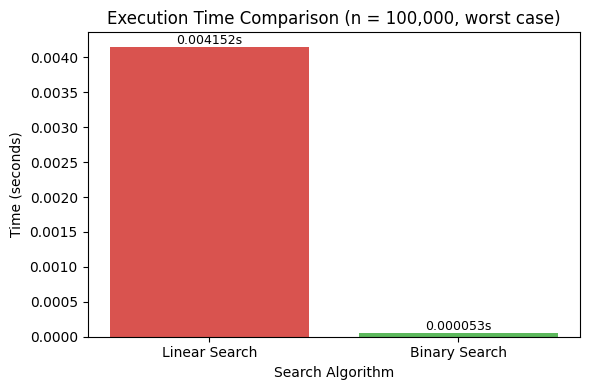

In [5]:
import matplotlib.pyplot as plt

algorithms = ["Linear Search", "Binary Search"]
times = [linear_time, binary_time]

plt.figure(figsize=(6, 4))
bars = plt.bar(algorithms, times, color=["#d9534f", "#5cb85c"])
plt.title("Execution Time Comparison (n = 100,000, worst case)")
plt.xlabel("Search Algorithm")
plt.ylabel("Time (seconds)")
for bar, t in zip(bars, times):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{t:.6f}s",
              ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

### Interpretation

The bar chart shows a dramatically taller bar for Linear Search and a near-invisible bar for Binary Search. This visually confirms the complexity analysis: Binary Search's O(log n) growth means that even a 100,000x increase in dataset size only adds a handful of extra comparisons, whereas Linear Search's O(n) cost grows in direct proportion to dataset size — a critical consideration for an e-commerce platform serving millions of product lookups under heavy traffic.